# Lab 01: Data wrangling and EDA

**You should add this to a personal Github repo and submit the link to the repo in Canvas.** Add your name to the top of this document and anyone you worked with.

The goal of this lab is to practice working with datasets using Pandas and explore a dataset with plotting and basic statistics. In particular, we will look at a plot to track flows (association between two categoricals): the alluvial diagram.

Here is your lab prompt: You are advising the University of Virginia’s Office of Development on opportunities to expand philanthropic support from international sources. Using the foreign-giving data provided, develop a short strategic plan identifying the countries, institutions, or donor segments UVA should prioritize for future engagement.

Your recommendations should be evidence-based. Use the data to identify patterns in giving, compare potential sources of support, and explain why particular markets or institutions appear especially promising. Support your conclusions with appropriate summaries and visualizations, and translate your findings into a small set of concrete recommendations for the Director of Development.,

1. In your first .ipynb or .py file called **initial_analysis** complete the following steps:
     1. Load the Foreign Gifts data.
     2. Describe the differences between different classes of gift types.
     3. Answer the following questions:
         1. Which country gives the most money in total?
         2. Which country initiates the most gifts by count?
         3. Which country gives the largest gifts on average?
         4. Which institution receive the most money in total?
         5. Which institution receive the greatest number of gifts by count?
         6. What is the average amount each university receives? Median amount? If they are different why?
         7. What is the largest flow of a single country to a single institution?
         8. Which are the top giftors to US academic institutions?
 2. In a new .ipynb/.py file called **uva_analysis**, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.
 3. In a document file (.doc, .docx, .pdf, etc.), summarize your findings:
     1. Executive Summary: What are your main findings and recommendations, in a single paragraph?
     2. Summarize the results of your initial analyses of overall giving and giving to UVA (1-3 paragraphs).
     3. Describe a strategy for finding new potential sources of money for UVA. What countries or institutions should UVA target, and why? (1-3 paragraphs)
     4. Conclude with a summary of UVA's prospects for increasing foreign giving. (1 paragraph).

 In total, your submission repo contain submit at least .ipynb/.py analysis files and a document file with your report (.doc, .docx, .pdf, etc.). If you divide the work among members of a group, make sure that you understand the code being written and submitted by the other members of your group.



## The standard stack: importing packages + reading in the data

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [4]:
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

There are 3 types of gifts that are given out to institutions, contract, monetary gifts, and real estate. Essentially, they are contracts made with the university to make or do something with money attached to the contract, monetary gifts is money just given to the institutions, and real estate is (what I assume) parcels of land or building given to a university. All of these have some kind money involved, meaning they could be classified as gifts. 

## Groupby

As we learned, `.groupby` is a super useful way to aggregate the data and explore summary statistics. We can assign the output to a new dataframe, just taking the n largest amounts. Resetting the index just changes the index to integers starting at 0. 

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>


In [2]:
total_by_country = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest().reset_index()
total_by_country.head()

,Country of Giftor,Foreign Gift Amount
0,QATAR,2706240869
1,ENGLAND,1464906771
2,CHINA,1237952112
3,SAUDI ARABIA,1065205930
4,BERMUDA,899593972


Qatar gives by far the most amount of money in total, nearly double what England gives. 

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


In [3]:
count_by_country = df.groupby('Country of Giftor')['Foreign Gift Amount'].count().nlargest().reset_index(name = "Count")
count_by_country.head()

,Country of Giftor,Count
0,ENGLAND,3655
1,CHINA,2461
2,CANADA,2344
3,JAPAN,1896
4,SWITZERLAND,1676


England gives the most gifts. 

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

In [4]:
average_by_country = df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().nlargest().reset_index(name = "Average")
average_by_country.head()

,Country of Giftor,Average
0,BERMUDA,7.688837e+06
1,ECUADOR,3.985140e+06
2,QATAR,3.905109e+06
3,ANTIGUA,3.435545e+06
4,JERSEY,3.064589e+06


Bermuda gives the largest gifts on average.

## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

In [ ]:
most_money_institution = df.groupby('Institution Name')['Foreign Gift Amount'].sum().nlargest(20).reset_index()
most_money_institution.head()



,Institution Name,Foreign Gift Amount
0,Carnegie Mellon University,1477922504
1,Cornell University,1289937761
2,Harvard University,954803610
3,Massachusetts Institute of Technology,859071692
4,Yale University,613441311


Carnegie Mellon University receives the most money in total

In [6]:
insitution_gift_count = df.groupby('Institution Name')['Foreign Gift Amount'].count().nlargest().reset_index(name = "Count")
insitution_gift_count.head()

# UCLA receives the most number of gifts in total

,Institution Name,Count
0,"University of California, Los Angeles",3916
1,California Institute of Technology,2502
2,Columbia University in the City of New York,1127
3,Ohio State University (The),1014
4,Johns Hopkins University,899


UCLA receives the most number of gifts in total

Text(0, 0.5, 'Institution Name')

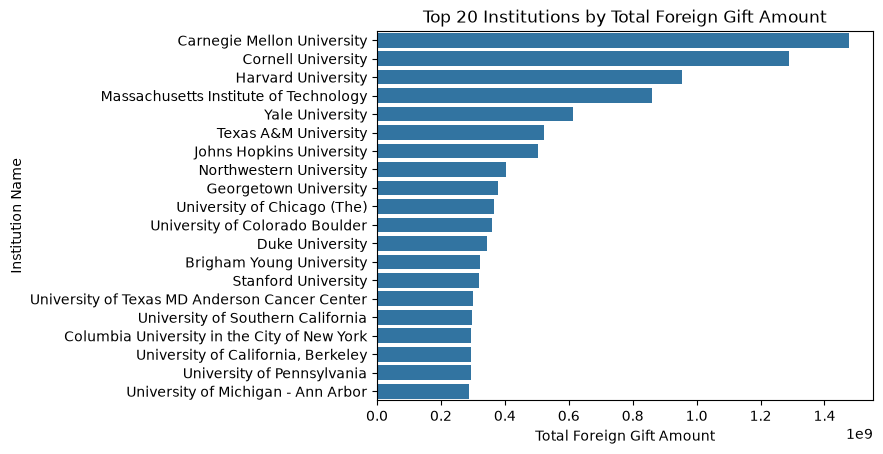

In [7]:
top_20_institutions = most_money_institution
sns.barplot(data=top_20_institutions, x='Foreign Gift Amount', y='Institution Name')
plt.title('Top 20 Institutions by Total Foreign Gift Amount')
plt.xlabel('Total Foreign Gift Amount')
plt.ylabel('Institution Name')


## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


In [13]:
most_money_institution_all = df.groupby('Institution Name')['Foreign Gift Amount'].sum().reset_index()

mean = most_money_institution_all['Foreign Gift Amount'].mean()
median = most_money_institution_all['Foreign Gift Amount'].median()

print(mean)
print(median)

52202878.974842764
6486791.5


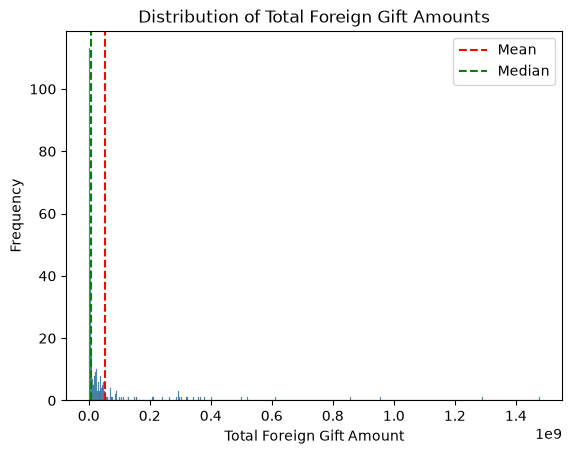

In [9]:
sns.histplot(data = most_money_institution_all, x='Foreign Gift Amount', bins = 500)
plt.title('Distribution of Total Foreign Gift Amounts')
plt.xlabel('Total Foreign Gift Amount')
plt.ylabel('Frequency')
plt.axvline(mean, color='r', linestyle='dashed', label='Mean')
plt.axvline(median, color='g', linestyle='dashed', label='Median')
plt.legend()


Mean is 52202878.97 and median is 6486791.5, mean is significantly larger than median because while the median is not going to be affected by large outlier gift amounts, the mean will, meaning it will skew the distribution to the right and raise the mean. 

## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [10]:
pd.crosstab(df['Country of Giftor'], df['Institution Name']).stack().nlargest(20)

Country of Giftor  Institution Name                           
ENGLAND            University of California, Los Angeles          964
CANADA             University of California, Los Angeles          533
CHINA              University of California, Los Angeles          485
JAPAN              University of California, Los Angeles          428
FRANCE             California Institute of Technology             426
CANADA             California Institute of Technology             363
QATAR              Texas A&M University                           352
HONG KONG          University of California, Los Angeles          301
SOUTH KOREA        California Institute of Technology             280
ENGLAND            California Institute of Technology             274
SWITZERLAND        Ohio State University (The)                    267
GERMANY            California Institute of Technology             260
JAPAN              California Institute of Technology             250
THE NETHERLANDS    Ohio Sta

England to UCLA is the largest flow of gifts from one country to one institution

### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>

In [11]:
total_by_giftor = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(20).reset_index()
total_by_giftor.head()

,Giftor Name,Foreign Gift Amount
0,Qatar Foundation,1166503744
1,Qatar Foundation/Qatar National Res,796197000
2,Qatar Foundation for Education,373945215
3,Anonymous,338793629
4,Saudi Arabian Cultural Mission,275221475


Qatar Foundations

<div class="alert alert-block alert-warning">
<b>Bonus:</b>  Plot the flows from giftors to institutions. 
</div>


In [12]:
import pandas as pd
import plotly.graph_objects as go

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()